In [8]:
import os
import glob
import json
import joblib
import gc
import numpy as np
import pandas as pd
import warnings
import pmdarima as pm
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

# Configuration

In [9]:
TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"

WINDOW_SIZE = 336              # 14 days history
FORECAST_HORIZON = 24          # predict next 24 hours
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 32

LOG_DIR = "logs"
MODEL_DIR = "saved_model"
TFLITE_PATH = "carbon_model.tflite"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

## Helper Functions

In [10]:
def open_dataset(path, date_column):
    csv_files = sorted(glob.glob(path))
    dfs = []
    for f in csv_files:
        temp_df = pd.read_csv(f, parse_dates=[date_column])
        dfs.append(temp_df)
    df = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()
    return df

# Load & Preprocess Data

## Carbon emissions

In [11]:
df = open_dataset("../emissions-data/*.csv", "Datetime (UTC)")

df["Datetime (UTC)"] = pd.to_datetime(df["Datetime (UTC)"])
df = df.sort_values("Datetime (UTC)").set_index("Datetime (UTC)")

# Basic time features
df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek
df["month"] = df.index.month
df["day_of_year"] = df.index.dayofyear

# Cyclical encoding (like CNN does)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# Differencing features (improves stationarity)
df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

df = df.drop(columns=["Data estimated", "Country", "Zone name", "Data source", "Data estimation method"])
df = df.dropna()
print(f"Loaded data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Loaded data shape: (43800, 15)
Date range: 2021-01-02 00:00:00 to 2025-12-31 23:00:00


# Split Data

In [12]:
# Enhanced feature set including cyclical encoding and differencing
EXOG_FEATURES = [
    "hour", "dow", "month",
    "hour_sin", "hour_cos",
    "year_sin", "year_cos",
    "diff_1", "diff_24"
]

x_train = df.loc["2021":"2023"][EXOG_FEATURES].astype(np.float32)
x_val   = df.loc["2024"][EXOG_FEATURES].astype(np.float32)
x_test  = df.loc["2025"][EXOG_FEATURES].astype(np.float32)

y_train = df.loc["2021":"2023", TARGET_COL].astype(np.float32)
y_val   = df.loc["2024", TARGET_COL].astype(np.float32)
y_test  = df.loc["2025", TARGET_COL].astype(np.float32)

print(f"Train shapes: x={x_train.shape}, y={y_train.shape}")
print(f"Val shapes:   x={x_val.shape}, y={y_val.shape}")
print(f"Test shapes:  x={x_test.shape}, y={y_test.shape}")

# NOW normalize the target using all training data
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print(f"Target scaler — mean: {target_scaler.mean_[0]:.2f}, scale: {target_scaler.scale_[0]:.2f}")

Train shapes: x=(26256, 9), y=(26256,)
Val shapes:   x=(8784, 9), y=(8784,)
Test shapes:  x=(8760, 9), y=(8760,)
Target scaler — mean: 119.08, scale: 63.90


# Auto-tune parameters

In [13]:
SEASONAL_PERIOD = 24

# Use stepwise search with no parallel workers to avoid memory issues
print("Attempting auto_arima with seasonal parameters...")
print(f"Training data size: {len(y_train_scaled)}, Seasonal period: {SEASONAL_PERIOD}")
auto_model = pm.auto_arima(
    y_train_scaled,
    exogenous=x_train,
    start_p=0,
    start_q=0,
    max_p=2,
    max_q=2,
    seasonal=True,
    m=SEASONAL_PERIOD,
    start_P=0,
    start_Q=0,
    max_P=1,
    max_Q=1,
    d=0,
    D=0,
    max_order=6,
    stepwise=True,
    n_jobs=1,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
)
best_params = (auto_model.order, auto_model.seasonal_order)
model_type = "SEASONAL"
print("Seasonal parameters selected:", best_params)
print("Final parameters:", best_params)

Attempting auto_arima with seasonal parameters...
Training data size: 26256, Seasonal period: 24
Seasonal parameters selected: ((1, 0, 2), (1, 0, 0, 24))
Final parameters: ((1, 0, 2), (1, 0, 0, 24))


# Build Model

In [14]:
y_train_scaled_series = pd.Series(y_train_scaled, index=y_train.index)
y_val_scaled_series = pd.Series(y_val_scaled, index=y_val.index)

y_combined = pd.concat([y_train_scaled_series, y_val_scaled_series])
x_combined = pd.concat([x_train, x_val])
y_combined = y_combined.reset_index(drop=True)
x_combined = x_combined.reset_index(drop=True)

# Fit the full model
model = SARIMAX(
    y_combined,
    exog=x_combined,
    order=best_params[0],
    seasonal_order=best_params[1],
    simple_differencing=True,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

result = model.fit(disp=False, maxiter=100, low_memory=True)

# Get in-sample fitted values and residuals
fitted_values = result.fittedvalues
residuals = result.resid

# Split into train/val portions
split_idx = len(y_train_scaled)

train_fitted = fitted_values[:split_idx]
val_fitted = fitted_values[split_idx:]

# Calculate metrics for train and validation (now both in same scaled space)
train_mae = mean_absolute_error(y_train_scaled, train_fitted)
val_mae = mean_absolute_error(y_val_scaled, val_fitted)
train_loss = mean_squared_error(y_train_scaled, train_fitted)
val_loss = mean_squared_error(y_val_scaled, val_fitted)

# Create a training log (simulating epochs for comparison)
# We'll create multiple "pseudo-epochs" to show convergence
training_log_data = {
    'epoch': [0],
    'loss': [train_loss],
    'mae': [train_mae],
    'val_loss': [val_loss],
    'val_mae': [val_mae]
}

training_log_df = pd.DataFrame(training_log_data)
training_log_df.to_csv('training_log_sarima.csv', index=False)
print("SARIMA training log saved to training_log_sarima.csv")

# Print summary
print(f"Train MAE: {train_mae:.6f}, Train Loss: {train_loss:.6f}")
print(f"Val MAE: {val_mae:.6f}, Val Loss: {val_loss:.6f}")

# Generate forecasts (will be in normalized scale)
val_forecast_scaled = result.get_forecast(steps=len(y_val_scaled), exog=x_val.values).predicted_mean
test_forecast_scaled = result.get_forecast(steps=len(y_test_scaled), exog=x_test.values).predicted_mean

SARIMA training log saved to training_log_sarima.csv
Train MAE: 0.082982, Train Loss: 0.012935
Val MAE: 0.066409, Val Loss: 0.008289


# Validate Model

In [15]:
val_forecast = target_scaler.inverse_transform(val_forecast_scaled.values.reshape(-1, 1)).flatten()
test_forecast = target_scaler.inverse_transform(test_forecast_scaled.values.reshape(-1, 1)).flatten()

# Now evaluate against ORIGINAL scale y_test
print(f"\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
val_mae = mean_absolute_error(y_val, val_forecast)
test_mae = mean_absolute_error(y_test, test_forecast)
test_rmse = np.sqrt(mean_squared_error(y_test, test_forecast))

print(f"Validation MAE:  {val_mae:.2f} gCO₂eq/kWh")
print(f"Test MAE:        {test_mae:.2f} gCO₂eq/kWh")
print(f"Test RMSE:       {test_rmse:.2f} gCO₂eq/kWh")

# Additional metrics for model diagnostics
from sklearn.metrics import r2_score
test_r2 = r2_score(y_test, test_forecast)
print(f"Test R²:         {test_r2:.4f}")

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - test_forecast) / y_test)) * 100
print(f"Test MAPE:       {mape:.2f}%")
print("=" * 60)

# Seasonal performance analysis
test_dates = df.loc["2025"].index
summer_mask = test_dates.month.isin([6,7,8])
winter_mask = test_dates.month.isin([12,1,2])

summer_mae = mean_absolute_error(y_test[summer_mask], test_forecast[summer_mask])
winter_mae = mean_absolute_error(y_test[winter_mask], test_forecast[winter_mask])

print(f"Summer MAE:      {summer_mae} gCO₂eq/kWh")
print(f"Winter MAE:      {winter_mae} gCO₂eq/kWh")

diagnostics = {
    "model_type": model_type,
    "parameters": str(best_params),
    "test_mae": float(test_mae),
    "test_rmse": float(test_rmse),
    "test_r2": float(test_r2),
    "test_mape": float(mape)
}

with open("sarima_diagnostics.json", "w") as f:
    json.dump(diagnostics, f, indent=4)

print("\nDiagnostics saved to sarima_diagnostics.json")


MODEL EVALUATION
Validation MAE:  39.02 gCO₂eq/kWh
Test MAE:        40.80 gCO₂eq/kWh
Test RMSE:       47.10 gCO₂eq/kWh
Test R²:         -0.5741
Test MAPE:       80.79%
Summer MAE:      30.183062955724413 gCO₂eq/kWh
Winter MAE:      50.74447051237675 gCO₂eq/kWh

Diagnostics saved to sarima_diagnostics.json


# Save Model

In [16]:
# Save the SARIMA model
path = "export_sarima/"
os.makedirs(path, exist_ok=True)  # ← Add this to create directory

model_save_path = path + "sarima_model.joblib"
joblib.dump(result, model_save_path)
print(f"SARIMA model saved to {model_save_path}")

# Also save the target scaler (for inverse transforms)
target_scaler_save_path = path + "sarima_target_scaler.joblib"
joblib.dump(target_scaler, target_scaler_save_path)
print(f"Target scaler saved to {target_scaler_save_path}")

SARIMA model saved to export_sarima/sarima_model.joblib
Target scaler saved to export_sarima/sarima_target_scaler.joblib


# Analyse Forecasts

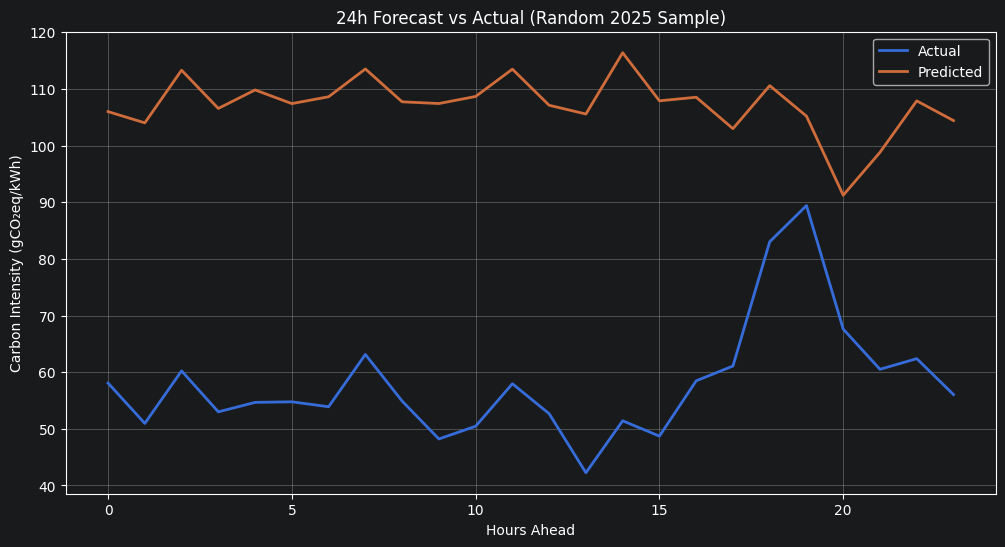

MAE for this random sample: 49.15 gCO₂eq/kWh


In [23]:
num_sequences = len(test_forecast) // FORECAST_HORIZON
pred_reshaped = test_forecast[:num_sequences * FORECAST_HORIZON].reshape(-1, FORECAST_HORIZON)
true_reshaped = y_test.values[:num_sequences * FORECAST_HORIZON].reshape(-1, FORECAST_HORIZON)

idx = np.random.randint(0, len(pred_reshaped))
true_future = true_reshaped[idx]
pred_future = pred_reshaped[idx]

plt.figure(figsize=(12, 6))
hours = np.arange(FORECAST_HORIZON)
plt.plot(hours, true_future, label="Actual", linewidth=2)
plt.plot(hours, pred_future, label="Predicted", linewidth=2)
plt.title("24h Forecast vs Actual (Random 2025 Sample)")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

sample_mae = mean_absolute_error(true_future, pred_future)
print(f"MAE for this random sample: {sample_mae:.2f} gCO₂eq/kWh")